# **UPLOADING DATASET**

In [20]:
# Upload dataset from your system
from google.colab import files
uploaded = files.upload()

Saving synthetic_social_media_data.csv to synthetic_social_media_data (1).csv


# **Import Libraries**

In [21]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# **Load Dataset**



In [22]:
# Load dataset
df = pd.read_csv('synthetic_social_media_data.csv')

# Clean column names:
# - Remove extra spaces
# - Convert to lowercase
# - Replace spaces with underscore
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Display first 5 rows
df.head()

,post_id,post_content,sentiment_label,number_of_likes,number_of_shares,number_of_comments,user_follower_count,post_date_and_time,post_type,language
0,aa391375-7355-44b7-bcbf-97fb4e5a2ba3,Word who nor center everything better politica...,Neutral,157,243,64,4921,2024-01-10 00:14:21,video,fr
1,1c9ec98d-437a-48d9-9cba-bd5ad853c59a,Begin administration population good president...,Positive,166,49,121,612,2024-02-03 00:20:11,image,es
2,170e5b5b-1d9a-4d02-a957-93c4dbb18908,Thousand total sign. Agree product relationshi...,Positive,185,224,179,9441,2024-07-25 14:20:23,video,de
3,aec53496-60ee-4a06-8821-093a04dc8770,Individual from news third. Oil forget them di...,Neutral,851,369,39,6251,2024-02-20 09:15:09,text,de
4,4eacddb7-990d-4056-8784-7e1d5c4d1404,Time adult letter see reduce. Attention sudden...,Negative,709,356,52,1285,2024-03-01 04:17:35,image,de


# **Dataset Overview**

In [23]:
# Basic information about dataset
df.info()

# Statistical summary of numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   post_id              2000 non-null   object
 1   post_content         2000 non-null   object
 2   sentiment_label      2000 non-null   object
 3   number_of_likes      2000 non-null   int64 
 4   number_of_shares     2000 non-null   int64 
 5   number_of_comments   2000 non-null   int64 
 6   user_follower_count  2000 non-null   int64 
 7   post_date_and_time   2000 non-null   object
 8   post_type            2000 non-null   object
 9   language             2000 non-null   object
dtypes: int64(4), object(6)
memory usage: 156.4+ KB


,number_of_likes,number_of_shares,number_of_comments,user_follower_count
count,2000.000000,2000.00000,2000.000000,2000.000000
mean,503.379000,248.48500,102.805000,5005.777000
std,283.210866,145.09499,58.032886,2913.865254
min,1.000000,0.00000,0.000000,3.000000
25%,267.000000,121.00000,52.000000,2383.250000
50%,505.000000,248.50000,104.500000,5048.500000
75%,740.000000,375.00000,153.250000,7556.500000
max,1000.000000,500.00000,200.000000,9999.000000


# **Text Preprocessing**

In [24]:
# Function to clean text data
def clean_text(text):
    # Handle missing values
    if not isinstance(text, str):
        return ""

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove mentions (@username)
    text = re.sub(r"@\w+", "", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Convert to lowercase
    return text.lower()

# Apply cleaning to 'post_content' column
df['cleaned_text'] = df['post_content'].apply(clean_text)

# Preview cleaned text
df[['post_content', 'cleaned_text']].head()

,post_content,cleaned_text
0,Word who nor center everything better politica...,word who nor center everything better politica...
1,Begin administration population good president...,begin administration population good president...
2,Thousand total sign. Agree product relationshi...,thousand total sign agree product relationship...
3,Individual from news third. Oil forget them di...,individual from news third oil forget them dif...
4,Time adult letter see reduce. Attention sudden...,time adult letter see reduce attention suddenl...


# **Sentiment Distribution**

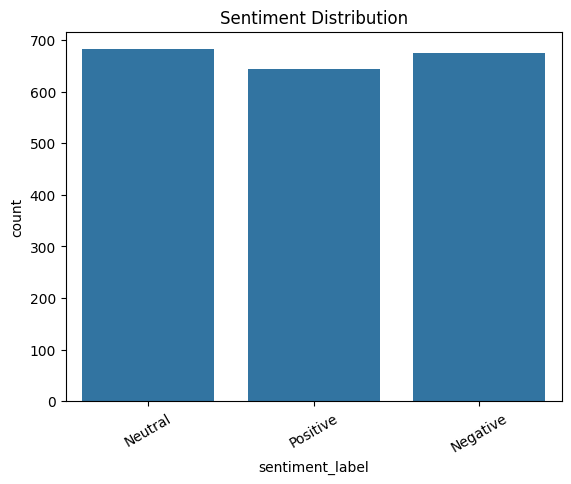

In [25]:
# Plot count of each sentiment category
sns.countplot(data=df, x='sentiment_label')

# Add title and rotate labels for readability
plt.title('Sentiment Distribution')
plt.xticks(rotation=30)

# Show plot
plt.show()

# **Engagement Analysis**

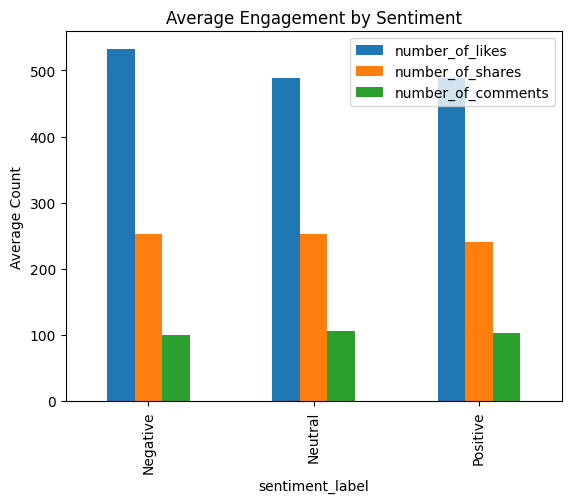

In [26]:
# Calculate average engagement metrics for each sentiment
engagement = df.groupby('sentiment_label')[[
    'number_of_likes',
    'number_of_shares',
    'number_of_comments'
]].mean()

# Plot bar chart
engagement.plot(kind='bar')

# Add labels
plt.title("Average Engagement by Sentiment")
plt.ylabel("Average Count")

plt.show()

# **Word Cloud**

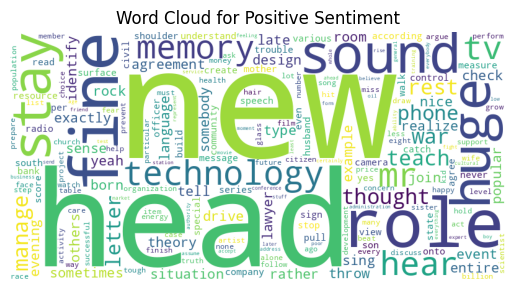

In [27]:
# Import WordCloud
from wordcloud import WordCloud

# Combine all positive sentiment text into one string
positive_text = " ".join(
    df[df['sentiment_label'].str.lower() == 'positive']['cleaned_text']
)

# Generate word cloud only if text exists
if positive_text.strip():
    wc = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

    plt.imshow(wc)
    plt.axis('off')
    plt.title("Word Cloud for Positive Sentiment")
    plt.show()
else:
    print("No positive sentiment data available")

# **Time-Based Analysis**

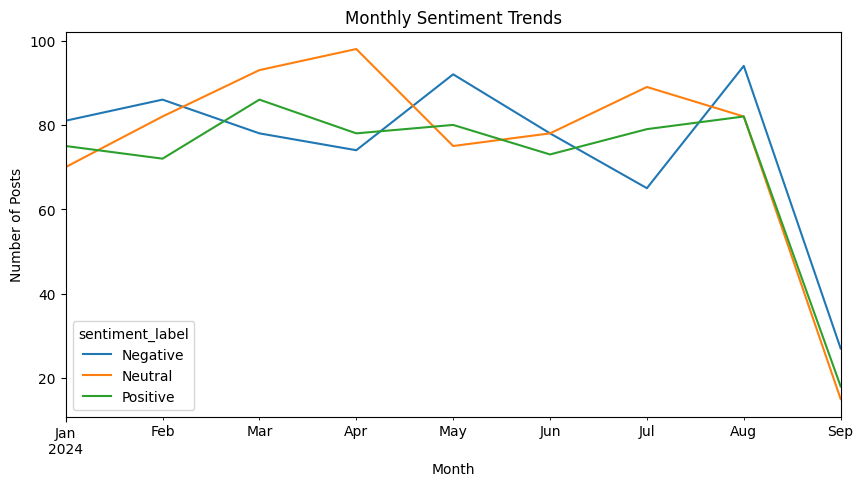

In [28]:
# Convert column to datetime format
df['post_date_and_time'] = pd.to_datetime(df['post_date_and_time'], errors='coerce')

# Extract month for grouping
df['month'] = df['post_date_and_time'].dt.to_period('M')

# Group data by month and sentiment
monthly = df.groupby(['month', 'sentiment_label']).size().unstack()

# Plot trends over time
monthly.plot(figsize=(10, 5))

plt.title("Monthly Sentiment Trends")
plt.xlabel("Month")
plt.ylabel("Number of Posts")

plt.show()

# **Post Type Distribution**

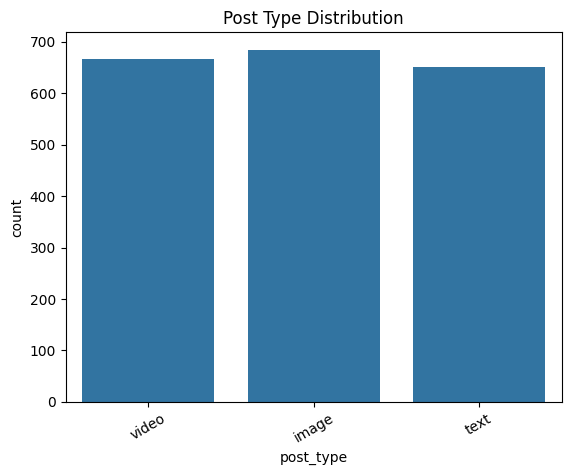

In [29]:
# Count posts based on type (image, video, etc.)
sns.countplot(data=df, x='post_type')

plt.title("Post Type Distribution")
plt.xticks(rotation=30)

plt.show()

# **Machine Learning Model**

In [30]:
# Import ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
X = df['cleaned_text']
y = df['sentiment_label']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert text to numerical vectors using TF-IDF
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train Naïve Bayes model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Predict on test data
y_pred = model.predict(X_test_vec)

# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.3575

Classification Report:
               precision    recall  f1-score   support

    Negative       0.35      0.54      0.42       121
     Neutral       0.39      0.33      0.36       149
    Positive       0.33      0.22      0.27       130

    accuracy                           0.36       400
   macro avg       0.36      0.36      0.35       400
weighted avg       0.36      0.36      0.35       400



# **Confusion Matrix**

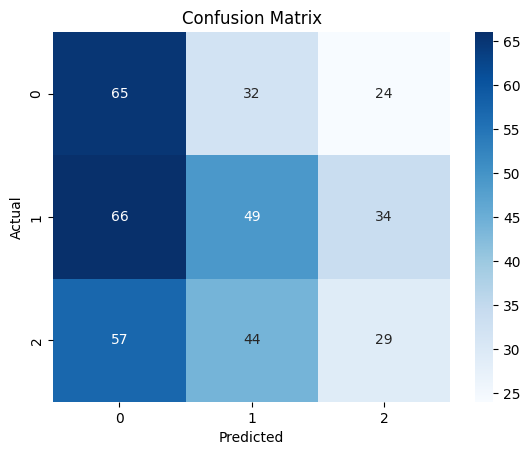

In [31]:
# Import confusion matrix tools
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()